In [1]:
import pandas as pd
import missingno as msno
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from matplotlib.patches import Patch

color_map = {
    'S1':   (0.25, 0.85, 0.35),   # verde vibrante
    'S2':  (0.85, 0.25, 0.35),   # vermelho vibrante
    'S3': (0.25, 0.25, 0.85),    # azul vibrante
    'S4': (0.85, 0.85, 0.25)     # amarelo vibrante
}

scenarios = ['S1', 'S2', 'S3', 'S4']

map_scenarios = {
    'S1': 'Sudden Drift',
    'S2': 'Gradual Drift',
    'S3': 'Recurrent Drift',
    'S4': 'Incremental Drift'
}

map_mechanisms = {
    'S1': {'index_0': 'MCAR', 'index_1': 'MAR'},
    'S2': {'index_0': 'MAR', 'index_1': 'MNAR', 'index_2': 'MAR', 'index_3': 'MNAR', 'index_4': 'MAR'},
    'S3': {'index_0': 'MNAR', 'index_1': 'MCAR', 'index_2': 'MNAR', 'index_3': 'MCAR', 'index_4': 'MNAR'},
    'S4': {'index_0': 'MAR', 'index_1': 'MNAR', 'index_2': 'MNAR', 'index_3': 'MNAR', 'index_4': 'MNAR', 'index_5': 'MNAR'}
}






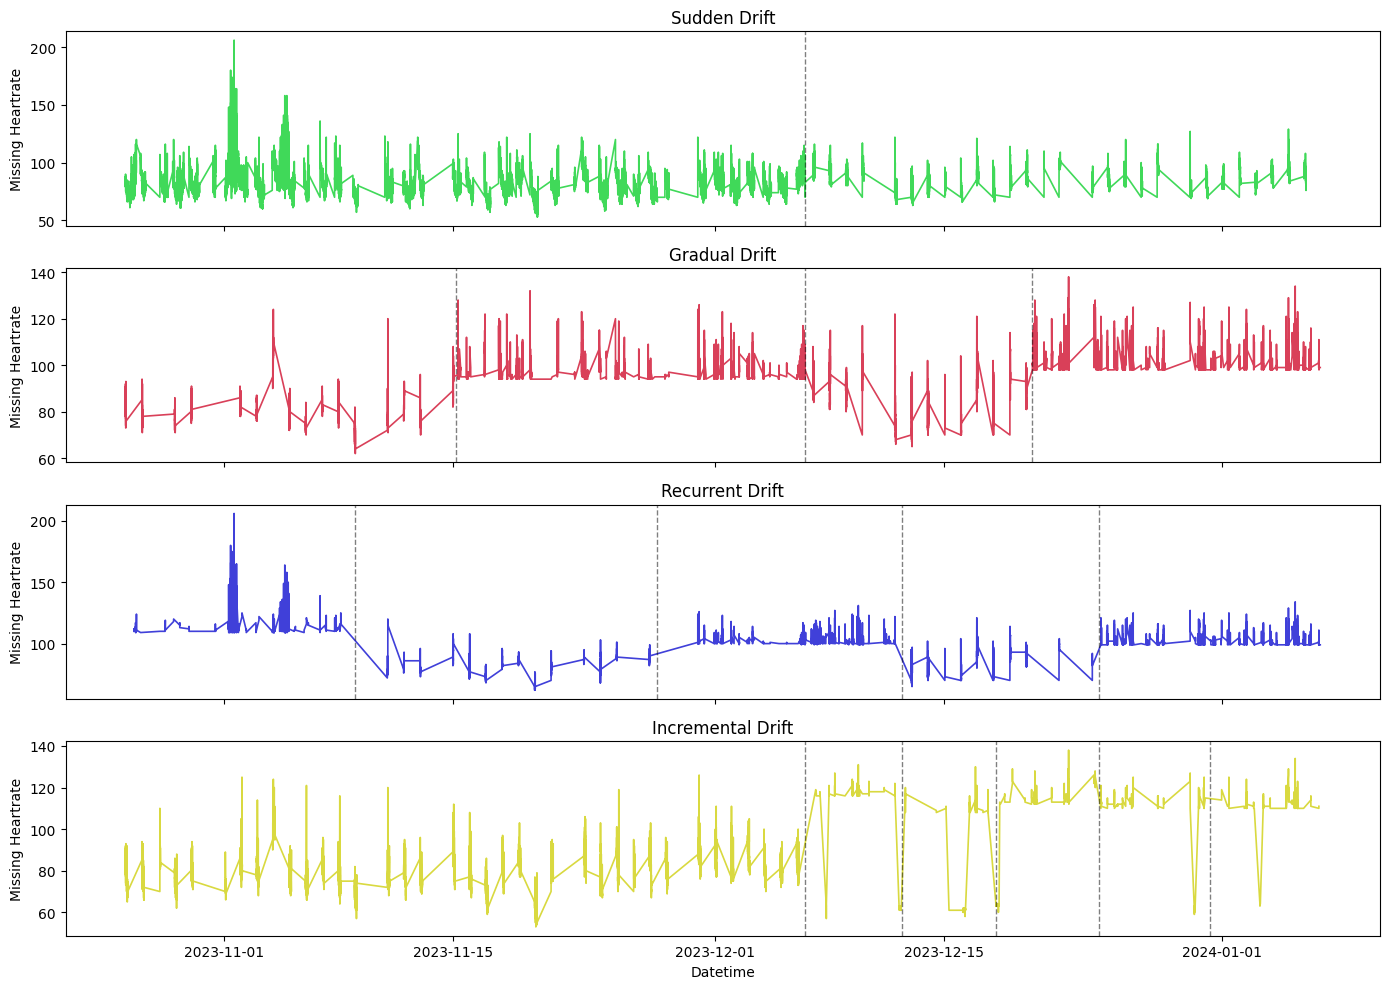

In [21]:
patient_id = 'A0NVTRV'
df_mec = {}
for mec in ['S1', 'S2', 'S3', 'S4']:
    df_mec[mec] = [pd.read_csv(os.path.join(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'), f)) 
                   for f in sorted(os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'))) if f.endswith('.csv')]

fig, axes = plt.subplots(
    nrows=len(scenarios),
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

step = 10000

for ax, mec in zip(axes, scenarios):

    # 🔵 Ler summary do cenário
    df_sum = pd.read_csv(
        os.path.join('..', 'Data', 'COVID-19-Wearables-MMD',
                     f'summary_{mec}_{30}.csv')
    )

    row_summary = df_sum[
        (df_sum["file_id"] == patient_id) &
        (df_sum["dataset_iteration"] == 1)
    ]

    split_cols = [c for c in row_summary.columns if c.startswith("index_")]

    splits = row_summary[split_cols].values.flatten()
    splits = splits[~pd.isna(splits)].astype(int)
    splits = sorted(splits)

    df = df_mec[mec][0].copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    df_plot = df[df["heartrate"].isna()]

    sns.lineplot(
        data=df_plot,
        # data=df_plot[::step],
        x="datetime",
        y="target",
        ax=ax,
        color=color_map[mec],
        linewidth=1.2
    )

    # 🔴 Linhas verticais dos splits
    for split_idx in splits[1:-1]:
        if split_idx < len(df):
            dt = df.iloc[split_idx]["datetime"]
            ax.axvline(
                x=dt,
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.5
            )

    ax.set_title(f"{map_scenarios.get(mec, mec)}")
    ax.set_ylabel("Missing Heartrate", fontsize=10)

axes[-1].set_xlabel("Datetime")

plt.tight_layout()
plt.savefig(f"Plots/missing_lines_{patient_id}.png", dpi=300)
plt.show()

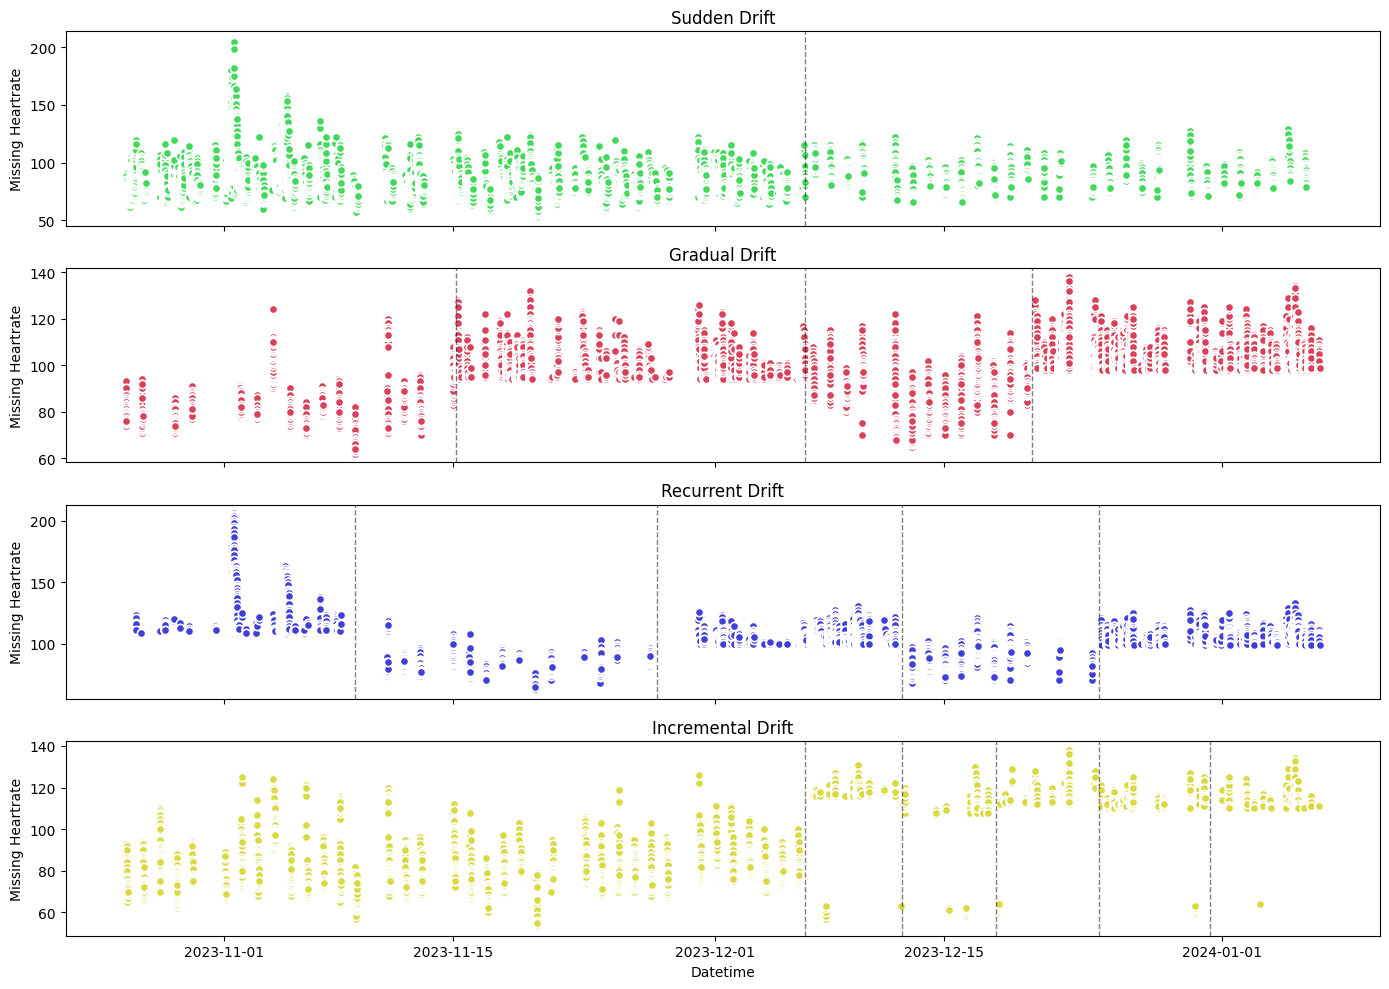

In [22]:
df_mec = {}
for mec in ['S1', 'S2', 'S3', 'S4']:
    df_mec[mec] = [pd.read_csv(os.path.join(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'), f)) 
                   for f in sorted(os.listdir(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mec, patient_id, '1'))) if f.endswith('.csv')]

fig, axes = plt.subplots(
    nrows=len(scenarios),
    ncols=1,
    figsize=(14, 10),
    sharex=True
)

step = 100

for ax, mec in zip(axes, scenarios):

    # 🔵 Ler summary do cenário
    df_sum = pd.read_csv(
        os.path.join('..', 'Data', 'COVID-19-Wearables-MMD',
                     f'summary_{mec}_{30}.csv')
    )

    row_summary = df_sum[
        (df_sum["file_id"] == patient_id) &
        (df_sum["dataset_iteration"] == 1)
    ]

    split_cols = [c for c in row_summary.columns if c.startswith("index_")]

    splits = row_summary[split_cols].values.flatten()
    splits = splits[~pd.isna(splits)].astype(int)
    splits = sorted(splits)

    df = df_mec[mec][0].copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    df["tuple_status"] = df["heartrate"].isna().map({
        True: "Missing",
        False: "Non-missing"
    })

    miss_color = {
        "Missing": color_map[mec],
        "Non-missing": (0.8, 0.8, 0.8)  # cinza claro para os não missing
    }

    df_plot = df[df["heartrate"].isna()]
    # df_plot = df.copy()

    # separar dados
    df_non_missing = df_plot[~df_plot["heartrate"].isna()]
    df_missing = df_plot[df_plot["heartrate"].isna()]

    # plot primeiro os não-missing
    sns.scatterplot(
        data=df_non_missing,
        x="datetime",
        y="target",
        ax=ax,
        color=(0.8, 0.8, 0.8),
        linewidth=1.2,
        legend=False
    )

    # depois os missing (ficam por cima)
    sns.scatterplot(
        data=df_missing,
        x="datetime",
        y="target",
        ax=ax,
        color=color_map[mec],
        linewidth=1.2,
        legend=False
    )

    # 🔴 Linhas verticais dos splits
    for split_idx in splits[1:-1]:
        if split_idx < len(df):
            dt = df.iloc[split_idx]["datetime"]
            ax.axvline(
                x=dt,
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.5
            )

    ax.set_title(f"{map_scenarios.get(mec, mec)}")
    ax.set_ylabel("Missing Heartrate", fontsize=10)

axes[-1].set_xlabel("Datetime")

plt.tight_layout()
plt.savefig(f"Plots/missing_patterns_{patient_id}.png", dpi=300)
plt.show()

In [4]:
def concat_data_all():
    mechanisms = ['S1', 'S2', 'S3', 'S4']
    patients = [p.split('_')[0] for p in os.listdir(os.path.join('..', '..', 'Datasets', 'COVID-19-Wearables')) if p.endswith('_hr.csv')]
 
    dist = {}
    for p in patients:
        if p in ['AJ7TSV9','AS2MVDL']:
            print(f"Skipping patient {p}")
            continue
        for n in range(1,2):
            for miss in ['30']:
                if miss not in dist:
                    dist[miss] = pd.DataFrame()
                for mech in mechanisms:
                    df_sum =  pd.read_csv(os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', f'summary_{mech}_{miss}.csv'))
                    row_summary = df_sum[
                        (df_sum["file_id"] == p) &
                        (df_sum["dataset_iteration"] == n)
                    ]
                    split_cols = [col for col in row_summary.columns if col.startswith("index_")]

                    splits = row_summary[split_cols].values.flatten()

                    path = os.path.join('..', 'Data', 'COVID-19-Wearables-MMD', mech, p, str(n))
                    df = pd.read_csv(os.path.join(path, f"{p}_hr_{mech}_{n}_{miss}.csv"))

                    nan_mask = df['heartrate'].isna()
                    nan_indices = df[nan_mask].index

                    target_values = df.loc[nan_mask, ['target']].copy()

                    target_values['mechanism'] = mech
                    target_values['miss'] = miss + '%'
                    target_values['patient'] = p

                    # 🔥 Criar coluna split
                    labels = [f"index_{i}" for i in range(len(splits) - 1)]

                    target_values['index'] = pd.cut(
                        nan_indices,
                        bins=splits,
                        labels=labels,
                        right=False
                    )

                    idx_str = target_values['index'].astype(str)
                    mech_map = map_mechanisms.get(mech, {})
                    target_values['mech'] = idx_str.map(mech_map).fillna(idx_str)

                    dist[miss] = pd.concat([dist[miss], target_values], ignore_index=True)

                    df_all = pd.concat([dist[miss] for miss in dist], ignore_index=True)
    return df_all, dist

df_all, df_miss = concat_data_all()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
print(df_all)

         target mechanism miss  patient    index  mech
0          85.0        S1  30%  A4E0D03  index_0  MCAR
1          82.0        S1  30%  A4E0D03  index_0  MCAR
2          87.0        S1  30%  A4E0D03  index_0  MCAR
3          96.0        S1  30%  A4E0D03  index_0  MCAR
4          98.0        S1  30%  A4E0D03  index_0  MCAR
...         ...       ...  ...      ...      ...   ...
6076690   103.0        S4  30%  A3OU183  index_5  MNAR
6076691   112.0        S4  30%  A3OU183  index_5  MNAR
6076692   104.0        S4  30%  A3OU183  index_5  MNAR
6076693   104.0        S4  30%  A3OU183  index_5  MNAR
6076694   110.0        S4  30%  A3OU183  index_5  MNAR

[6076695 rows x 6 columns]


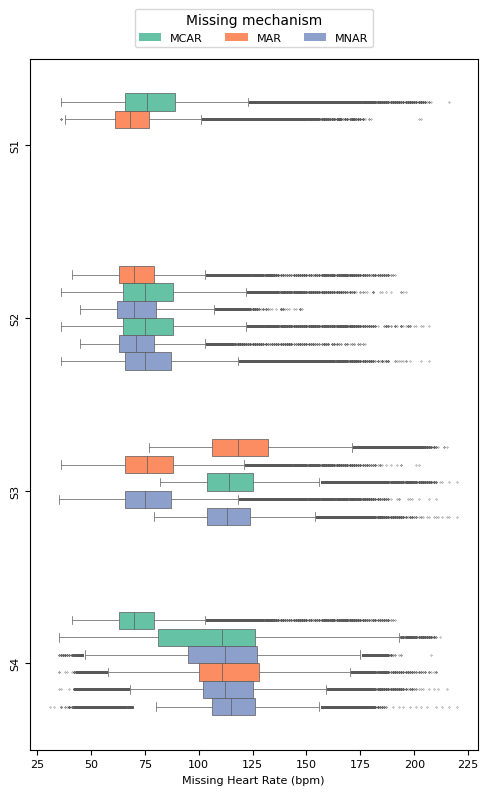

In [ ]:
palette_mech = {
    'MCAR': '#66c2a5',
    'MAR': '#fc8d62',
    'MNAR': '#8da0cb'
}

plt.figure(figsize=(5,8))

ax = sns.boxplot(
    data=df_all,
    x='target',
    y='mechanism',
    hue='index',
    palette='Set2',
    fliersize=0.3,
    linewidth=0.5,
    width=0.6
)

# obter a ordem dos boxes
box_data = (
    df_all[['mechanism','index','mech']]
    .drop_duplicates()
    .sort_values(['mechanism','index'])
)

# recolorir
for patch, (_, row) in zip(ax.patches, box_data.iterrows()):
    patch.set_facecolor(palette_mech[row['mech']])

plt.xlabel('Missing Heart Rate (bpm)', fontsize=8)
plt.ylabel('')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8, rotation=90, va = 'center')

# remover legenda antiga
ax.legend_.remove()

# nova legenda baseada nos mechanisms
handles = [
    Patch(facecolor=color, label=mech)
    for mech, color in palette_mech.items()
]

ax.legend(
    handles=handles,
    title="Missing mechanism",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3,
    fontsize=8
)

plt.tight_layout()
plt.savefig("Plots/missing_boxplot.png", dpi=300)
plt.show()